In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt
import os
import scipy.sparse as sp

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugi

In [2]:
%load_ext autoreload
%autoreload 2

## 1) Different magnetic equilibrium (USN)

missing keys: 0
unexpected keys: 0
Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy
0.0 1.0 (100, 4800)
noise std added to tomo data: 0.25


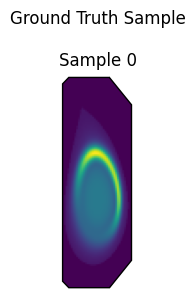

In [3]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

sample_idx = 9 #122, 2 , 9, 12     7,21
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

sigma_y_tomo = 0.25
flip_radially = False
flip_vertically = True
if flip_radially:
    x_gt = torch.flip(x_gt, dims=[-1])  # flip horizontally (radially)
if flip_vertically:
    x_gt = torch.flip(x_gt, dims=[-2])  # flip vertically
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)
print("noise std added to tomo data:", sigma_y_tomo)

show_samples(x_gt, title="Ground Truth Sample")

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

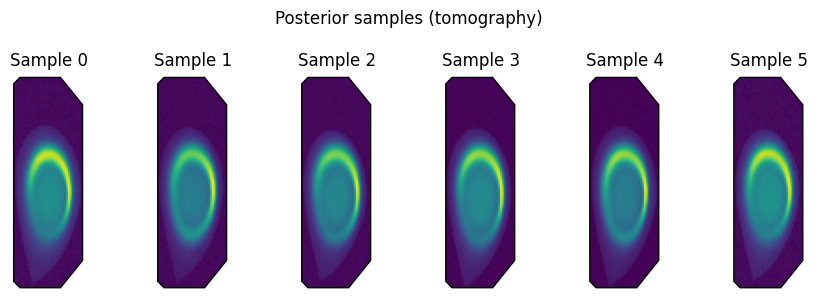

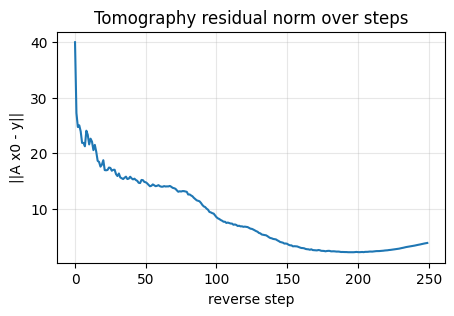

In [4]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100, 
    clip_range=None,
    reaction_diffusion_op=None,
    lambda_rd=1e-15,
)

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


In [6]:
sigma_err = sigma_y_tomo
anis_param = 5e-3
reg_param = 1e-1
with_positivity_constraint = True

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
if flip_radially:
    psi_flipped = np.flip(psi, -1)  # flip horizontally (radially)
if flip_vertically:
    psi_flipped = np.flip(psi, -2)  # flip vertically
else:
    psi_flipped=psi

noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_) 
if flip_radially:
    mask_core = np.flip(mask_core, -1)  # flip horizontally (radially)
if flip_vertically:
    mask_core = np.flip(mask_core, -2)  # flip vertically

# f = fct_def._DataFidelityFunctional(
#     dim_shape=(1, H, W),
#     noisy_tomo_data=noisy_tomo_data,
#     sigma_err=sigma_err,
#     geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
# )
# g = AnisDiffusionOp(
#     dim_shape=(1, H, W),
#     alpha=anis_param,
#     diff_method_struct_tens="fd",
#     freezing_arr=psi_flipped,
#     sampling=0.0125,
#     matrix_based_impl=True,
# )

f, g = fct_def.define_loglikelihoodfromdata_and_logprior(
                    noisy_tomo_data.flatten(),
                    psi_flipped,
                    fwd_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
                    reconstruction_shape=(1, H, W),
                    sigma_err=sigma_err,
                    reg_fct_type='anisotropic',
                    alpha=1e-2,
                    sampling=0.0125,
                )

anis_param_data = hyper_tune.anis_param_tuning(
                    f, g,
                    reg_param=reg_param,
                    tuning_techniques=["CV_full"],
                    with_pos_constraint=True,
                    clipping_mask=mask_core,
                    cv_strategy=["random"],
                    anis_params=np.logspace(-4, 0, 13),
                    plot=False,
                )
best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
# best_anis_param=2e-3

# ------------------------------------------------------------------
# Redefine regularization functional with tuned alpha
# ------------------------------------------------------------------
g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)


im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=mask_core,
    show_progress=True,
) #* scaling_factor 

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

Tuning regularization parameter: 5-fold cross validation (`CV_full`)

INFO -- [2026-05-01 16:16:23.394845] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


INFO -- [2026-05-01 16:16:23.947148] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-01 16:16:24.248033] Iteration 1_546
	iteration: 1546
	N_iter: 1547
	RelError[x]: 0
INFO -- [2026-05-01 16:16:24.248823] Stopping Criterion satisfied -> END


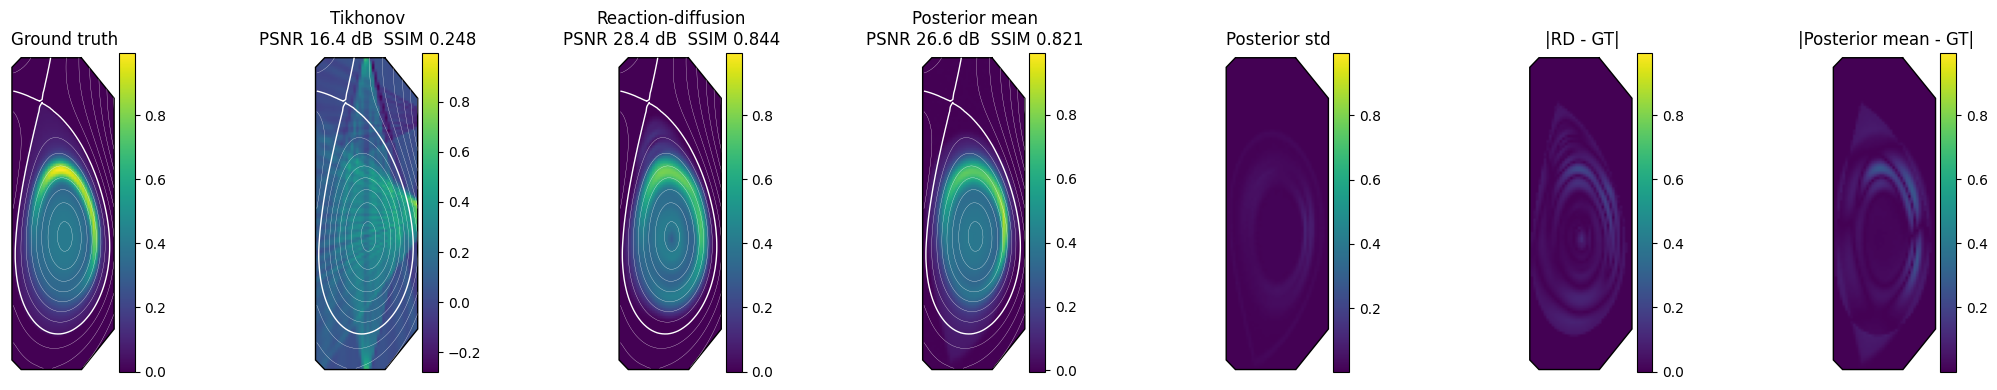

In [8]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std  = posterior_tomo.std(dim=0, keepdim=True) 

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir = (post_mean - x_gt).abs()
diff_map     = (x_map.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    return f"PSNR {p:.1f} dB  SSIM {s:.3f}"

summary = torch.stack([
        x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
    diff_map[0, 0].cpu(),
    diff_diffpir[0, 0].cpu(),
])

show_samples(
    summary,
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion\n{metrics(x_map.to(device))}",
        f"Posterior mean\n{metrics(post_mean)}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi_flipped, psi_flipped, psi_flipped, psi_flipped, None, None, None],
    colorbar=True,
    vmax=x_gt[0, 0].cpu().max(),#,[x_gt[0, 0].cpu().max(), None, x_gt[0, 0].cpu(), x_gt[0, 0].cpu(), None, None, None]
    #vmax = x_gt.abs().max().item()
)

## 2a) outer strikepoint radiation blob

Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy
noise std added to tomo data: 0.25


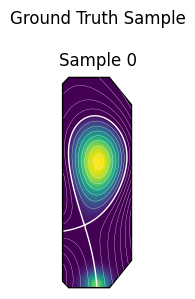

In [100]:
sample_idx = 21 #122, 2 , 9, 12     7,21
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx].astype(np.float32)

        # Gaussian blob parameters (edit as needed)
        std = 5.0
        z_idx, r_idx = H-3, W // 2 - 1
        amp = 1.0

        zz, rr = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
        blob = amp * np.exp(-((zz - z_idx) ** 2 + (rr - r_idx) ** 2) / (2 * std**2))

        x_np += 0.8*blob.astype(np.float32)
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

sigma_y_tomo = 0.25
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)
sigma_y_tomo_est = estimate_noise_std(y_tomo.cpu().reshape(1,-1))
print("noise std added to tomo data:", sigma_y_tomo)

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]

show_samples(x_gt, contour_images=[psi], title="Ground Truth Sample")

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

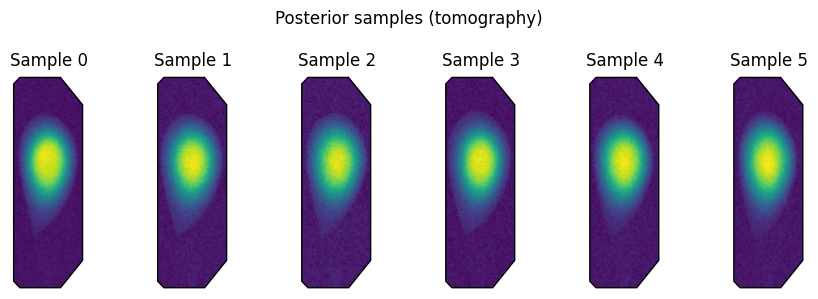

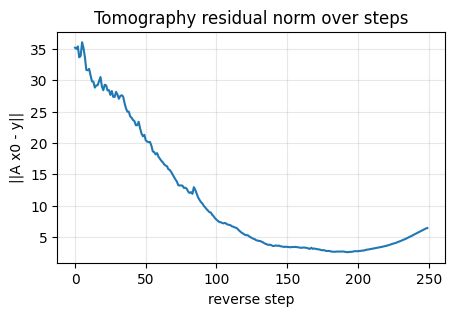

In [103]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100, 
    clip_range=None,
    reaction_diffusion_op=None,
    lambda_rd=1e-15,
)

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


In [101]:
sigma_err = sigma_y_tomo
anis_param = 5e-3
reg_param = 1e-1
with_positivity_constraint = True

noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_) 

f, g = fct_def.define_loglikelihoodfromdata_and_logprior(
                    noisy_tomo_data.flatten(),
                    psi,
                    fwd_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
                    reconstruction_shape=(1, H, W),
                    sigma_err=sigma_err,
                    reg_fct_type='anisotropic',
                    alpha=1e-2,
                    sampling=0.0125,
                )

# anis_param_data = hyper_tune.anis_param_tuning(
#                     f, g,
#                     reg_param=reg_param,
#                     tuning_techniques=["CV_full"],
#                     with_pos_constraint=True,
#                     clipping_mask=tcv_mask,
#                     cv_strategy=["random"],
#                     anis_params=np.logspace(-4, 0, 13),
#                     plot=False,
#                 )
# best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
# best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
best_anis_param = 1e-2

# ------------------------------------------------------------------
# Redefine regularization functional with tuned alpha
# ------------------------------------------------------------------
g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)


im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=tcv_mask,
    show_progress=True,
) #* scaling_factor 

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

INFO -- [2026-05-01 16:57:53.455180] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


INFO -- [2026-05-01 16:57:54.025009] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-01 16:57:54.394481] Iteration 1_652
	iteration: 1652
	N_iter: 1653
	RelError[x]: 0
INFO -- [2026-05-01 16:57:54.394885] Stopping Criterion satisfied -> END


In [12]:
best_anis_param

np.float64(0.01)

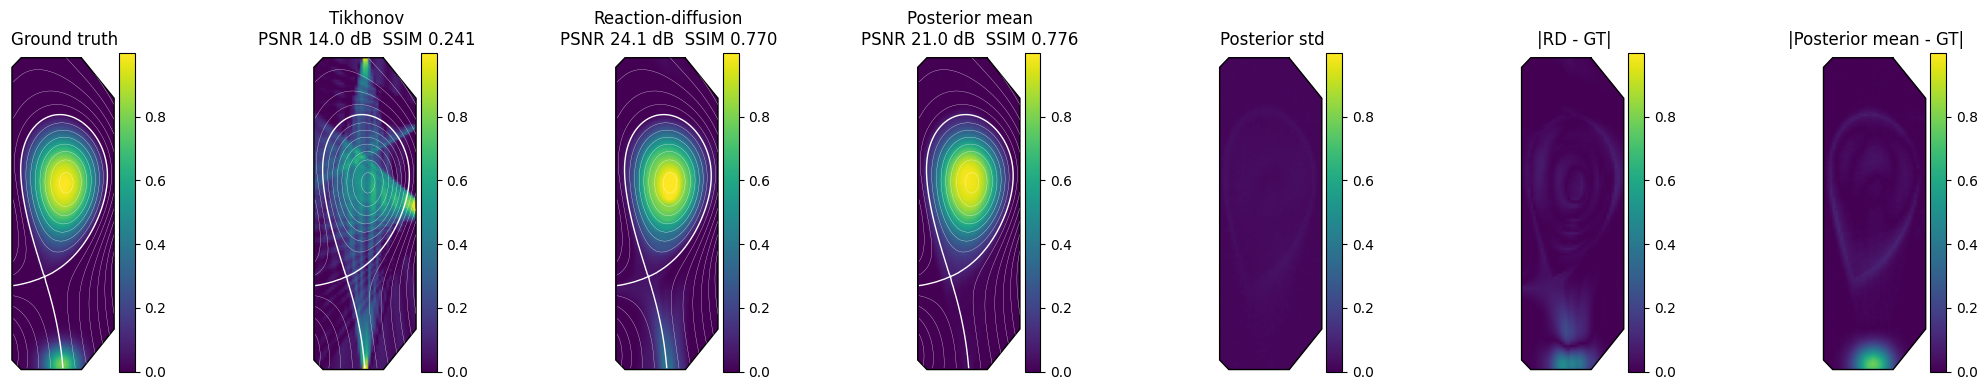

In [104]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std  = posterior_tomo.std(dim=0, keepdim=True) 

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir = (post_mean - x_gt).abs()
diff_map     = (x_map.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    return f"PSNR {p:.1f} dB  SSIM {s:.3f}"

summary = torch.stack([
        x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
    diff_map[0, 0].cpu(),
    diff_diffpir[0, 0].cpu(),
])

show_samples(
    summary,
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion\n{metrics(x_map.to(device))}",
        f"Posterior mean\n{metrics(post_mean)}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
    vmax=x_gt[0, 0].cpu().max(),#,[x_gt[0, 0].cpu().max(), None, x_gt[0, 0].cpu(), x_gt[0, 0].cpu(), None, None, None]
    vmin=0,
    #vmax = x_gt.abs().max().item()
)

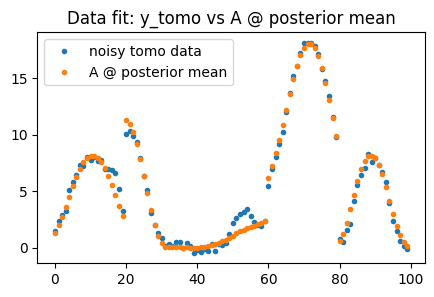

Text(0.5, 1.0, 'Data fit: y_tomo vs A @ RD_MAP_estimate')

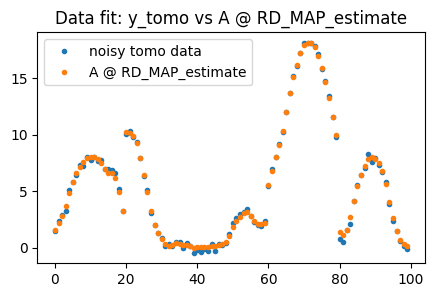

In [33]:
plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ post_mean.view(-1).cpu().numpy(), '.', label="A @ posterior mean")
plt.legend()
plt.title("Data fit: y_tomo vs A @ posterior mean")
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ x_map.view(-1).cpu().numpy(), '.', label="A @ RD_MAP_estimate")
plt.legend()
plt.title("Data fit: y_tomo vs A @ RD_MAP_estimate")

## 2a) inner strikepoint radiation blob

Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy
noise std added to tomo data: 0.25


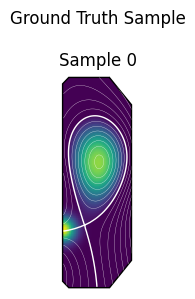

In [35]:
sample_idx = 21 #122, 2 , 9, 12     7,21
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx].astype(np.float32)

        # Gaussian blob parameters (edit as needed)
        std = 5.0
        z_idx, r_idx = H-34, 0
        amp = 1.0

        zz, rr = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
        blob = amp * np.exp(-((zz - z_idx) ** 2 + (rr - r_idx) ** 2) / (2 * std**2))

        x_np += 1.2*blob.astype(np.float32)
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

sigma_y_tomo = 0.25
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)
sigma_y_tomo_est = estimate_noise_std(y_tomo.cpu().reshape(1,-1))
print("noise std added to tomo data:", sigma_y_tomo)

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]

show_samples(x_gt, contour_images=[psi], title="Ground Truth Sample")

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

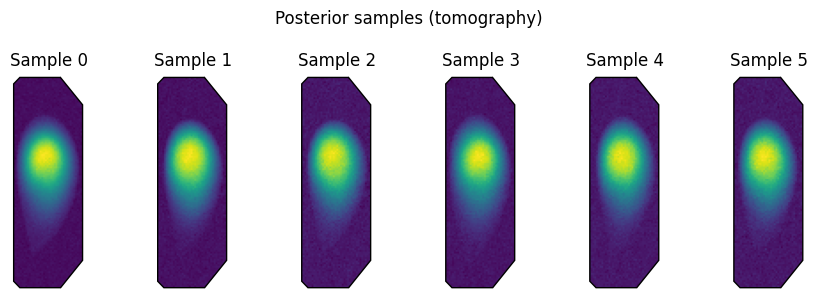

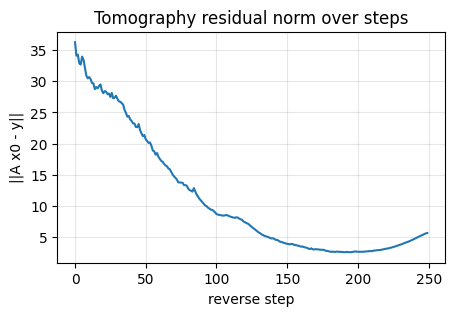

In [36]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100, 
    clip_range=None,
    reaction_diffusion_op=None,
    lambda_rd=1e-15,
)

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


In [27]:
sigma_err = sigma_y_tomo
reg_param = 1e-1
with_positivity_constraint = True

noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_) 

f, g = fct_def.define_loglikelihoodfromdata_and_logprior(
                    noisy_tomo_data.flatten(),
                    psi,
                    fwd_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
                    reconstruction_shape=(1, H, W),
                    sigma_err=sigma_err,
                    reg_fct_type='anisotropic',
                    alpha=1e-2,
                    sampling=0.0125,
                )

anis_param_data = hyper_tune.anis_param_tuning(
                    f, g,
                    reg_param=reg_param,
                    tuning_techniques=["CV_full"],
                    with_pos_constraint=True,
                    clipping_mask=tcv_mask,
                    cv_strategy=["random"],
                    anis_params=np.logspace(-4, 0, 13),
                    plot=False,
                )
best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
# best_anis_param = 4e-3

# ------------------------------------------------------------------
# Redefine regularization functional with tuned alpha
# ------------------------------------------------------------------
g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)


im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=tcv_mask,
    show_progress=True,
) #* scaling_factor 

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

Tuning regularization parameter: 5-fold cross validation (`CV_full`)

INFO -- [2026-05-01 16:23:50.735361] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


INFO -- [2026-05-01 16:23:51.294743] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-01 16:23:51.653421] Iteration 1_644
	iteration: 1644
	N_iter: 1645
	RelError[x]: 0
INFO -- [2026-05-01 16:23:51.654358] Stopping Criterion satisfied -> END


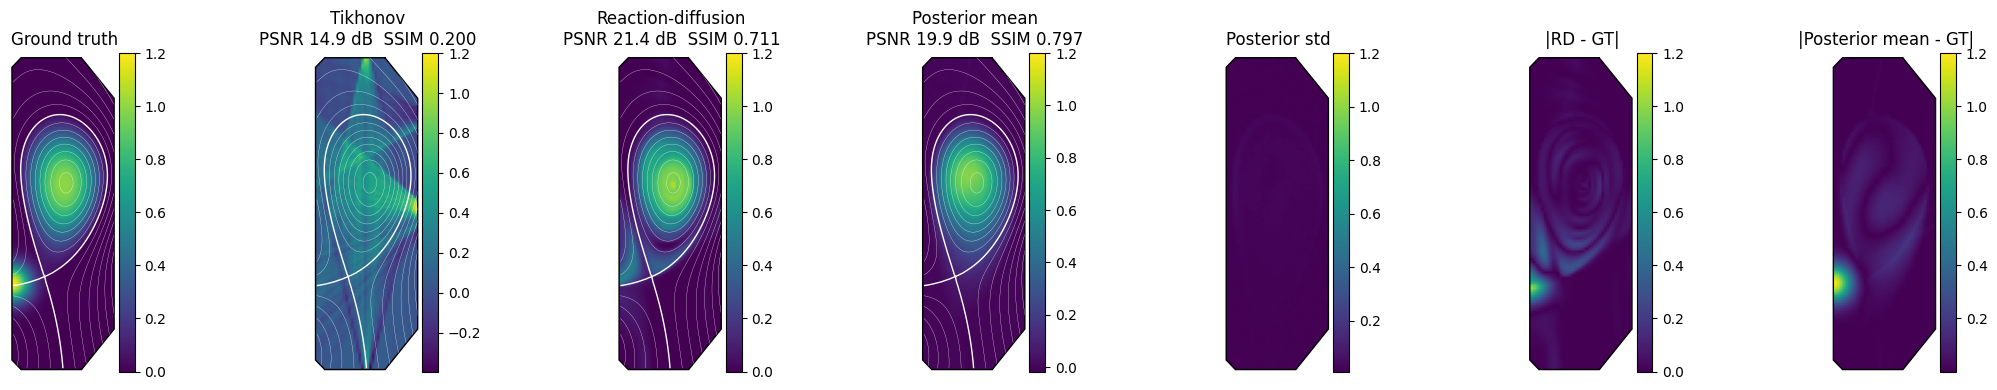

In [37]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std  = posterior_tomo.std(dim=0, keepdim=True) 

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir = (post_mean - x_gt).abs()
diff_map     = (x_map.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    return f"PSNR {p:.1f} dB  SSIM {s:.3f}"

summary = torch.stack([
        x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
    diff_map[0, 0].cpu(),
    diff_diffpir[0, 0].cpu(),
])

show_samples(
    summary,
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion\n{metrics(x_map.to(device))}",
        f"Posterior mean\n{metrics(post_mean)}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
    vmax=x_gt[0, 0].cpu().max(),#,[x_gt[0, 0].cpu().max(), None, x_gt[0, 0].cpu(), x_gt[0, 0].cpu(), None, None, None]
    #vmax = x_gt.abs().max().item()
)

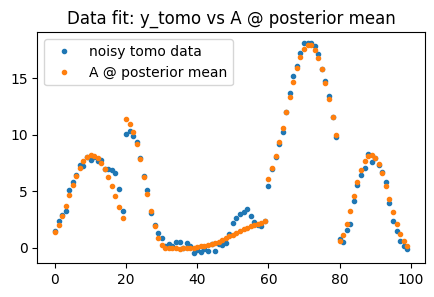

Text(0.5, 1.0, 'Data fit: y_tomo vs A @ RD_MAP_estimate')

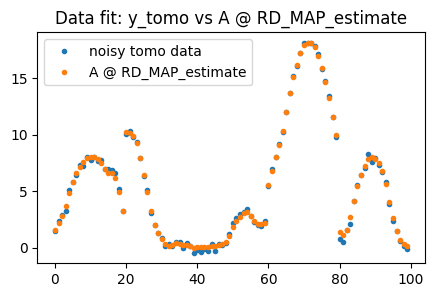

In [38]:
plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ post_mean.view(-1).cpu().numpy(), '.', label="A @ posterior mean")
plt.legend()
plt.title("Data fit: y_tomo vs A @ posterior mean")
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ x_map.view(-1).cpu().numpy(), '.', label="A @ RD_MAP_estimate")
plt.legend()
plt.title("Data fit: y_tomo vs A @ RD_MAP_estimate")

## 3) Doublets

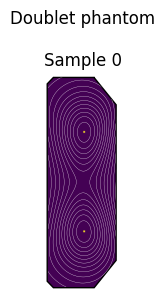

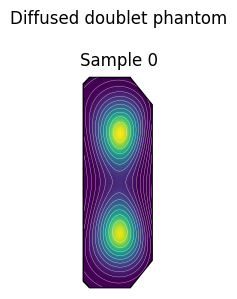

In [94]:
import scipy.io as scio
from scipy import ndimage

def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        # convert inversion grid coordinates to image coordinates
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            # for doublet, flip the original equilibrium to match the new grid orientation
             eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                            coord_eval_pos, order=2, mode="nearest",
                                                            prefilter=True).reshape(Nz, Nr)
        else:
            # evaluate original fbte input on the prescribed inversion grid
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                                coord_eval_pos, order=2, mode="nearest",
                                                                prefilter=True).reshape(Nz, Nr)
    return eqs

# create doublet phantom
doublet_phantom=np.zeros((H,W))

# load experimental data and preprocess to get psi on the inversion grid
exp_data = scio.loadmat('experimental_data/shot_data_87262.mat')['data'][0, 0] # doublet
psi_doublet=preprocess_magnetic_data(exp_data, Nz=120, Nr=40, doublet=True)[26]

# place two pixels of value 1 at the expected doublet location based on the psi contours, as starting poitn of diffusion process
doublet_phantom[31,21], doublet_phantom[87,21] = 1.0, 1.0
show_samples(torch.from_numpy(doublet_phantom).view(1,1,H,W), title="Doublet phantom", contour_images=[psi_doublet])
doublet_phantom = doublet_phantom.flatten()

reg_fct = AnisDiffusionOp(dim_shape=(1,H,W),
                                           alpha=5e-2,
                                           diff_method_struct_tens="fd",
                                           freezing_arr=psi_doublet,
                                           sampling=0.0125,
                                           matrix_based_impl=True)
clip_each_iter = True
clipping_outside_core = True
diffusive_steps = int(3e3)
core_mask=np.zeros((H, W), dtype=bool)
core_mask[np.where(psi_doublet>0.41)] = True
for s in range(diffusive_steps):
    # 2/L with L=8 seems enough, L=8 good estimate of diff_lipschitz constant of reg_fct in principle..
    doublet_phantom -= 0.95 * (0.25 * (0.0125 ** 2)) * reg_fct._grad_matrix_based.mat.dot(doublet_phantom)
    if clip_each_iter:
        doublet_phantom[doublet_phantom < 0] = 0
    if clipping_outside_core:
        doublet_phantom *= core_mask.flatten()
doublet_phantom[doublet_phantom < 0] = 0

# normalize sample to 1
doublet_phantom /= doublet_phantom.max()

# plot result
show_samples(torch.from_numpy(doublet_phantom).view(1,1,H,W), title="Diffused doublet phantom", contour_images=[psi_doublet])

doublet_phantom = doublet_phantom.reshape(H, W)
x_gt = torch.from_numpy(doublet_phantom.astype(np.float32)).to(device).view(1, 1, H, W)

# obtained results is x_gt; compute tomographic data
y_doublet = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

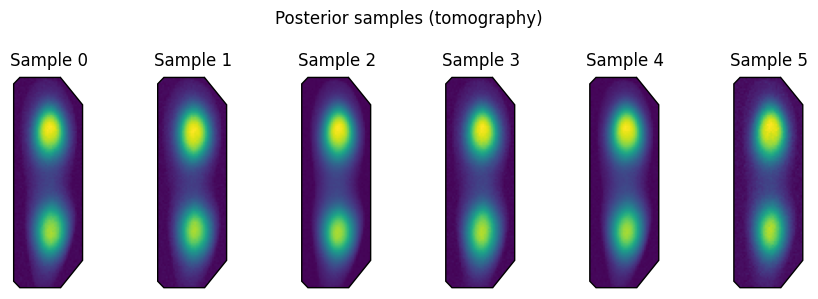

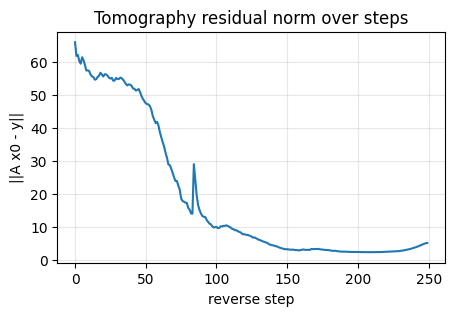

In [95]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_doublet,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100, 
    clip_range=None,
    reaction_diffusion_op=None,
    lambda_rd=1e-15,
)

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)

plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals)
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.grid(True, alpha=0.3)
plt.show()


In [96]:
sigma_err = sigma_y_tomo
reg_param = 1e-1
with_positivity_constraint = True

noisy_tomo_data = y_doublet.cpu().numpy().reshape(1, -1)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi_doublet, dim_shape=(H, W), trim_values_x=trim_val_) 

f, g = fct_def.define_loglikelihoodfromdata_and_logprior(
                    noisy_tomo_data.flatten(),
                    psi_doublet,
                    fwd_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
                    reconstruction_shape=(1, H, W),
                    sigma_err=sigma_err,
                    reg_fct_type='anisotropic',
                    alpha=1e-2,
                    sampling=0.0125,
                )

anis_param_data = hyper_tune.anis_param_tuning(
                    f, g,
                    reg_param=reg_param,
                    tuning_techniques=["CV_full"],
                    with_pos_constraint=True,
                    clipping_mask=tcv_mask,
                    cv_strategy=["random"],
                    anis_params=np.logspace(-4, 0, 13),
                    plot=False,
                )
best_anis_idx   = np.argmin(anis_param_data["CV_full_random"][1, :])
best_anis_param = anis_param_data["CV_full_random"][0, best_anis_idx]
# best_anis_param = 2e-2

# ----------------------------------------------    --------------------
# Redefine regularization functional with tuned alpha
# ------------------------------------------------------------------
g = hyper_tune._redefine_anis_param_logprior(g, best_anis_param)


im_map = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=tcv_mask,
    show_progress=True,
) #* scaling_factor 

x_map = torch.from_numpy(im_map).float().view(1, 1, H, W)

Tuning regularization parameter: 5-fold cross validation (`CV_full`)

INFO -- [2026-05-01 16:56:13.464600] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0


/home/dhamm/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu_diffops/operator/diffusion/_diffusion_coeff.py:147: UserWarning: DiffusionCoefficient had already been frozen. Overwriting previous frozen state.
  warnings.warn("DiffusionCoefficient had already been frozen. Overwriting previous frozen state.")


INFO -- [2026-05-01 16:56:14.025705] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-01 16:56:14.384164] Iteration 1_640
	iteration: 1640
	N_iter: 1641
	RelError[x]: 0
INFO -- [2026-05-01 16:56:14.384969] Stopping Criterion satisfied -> END


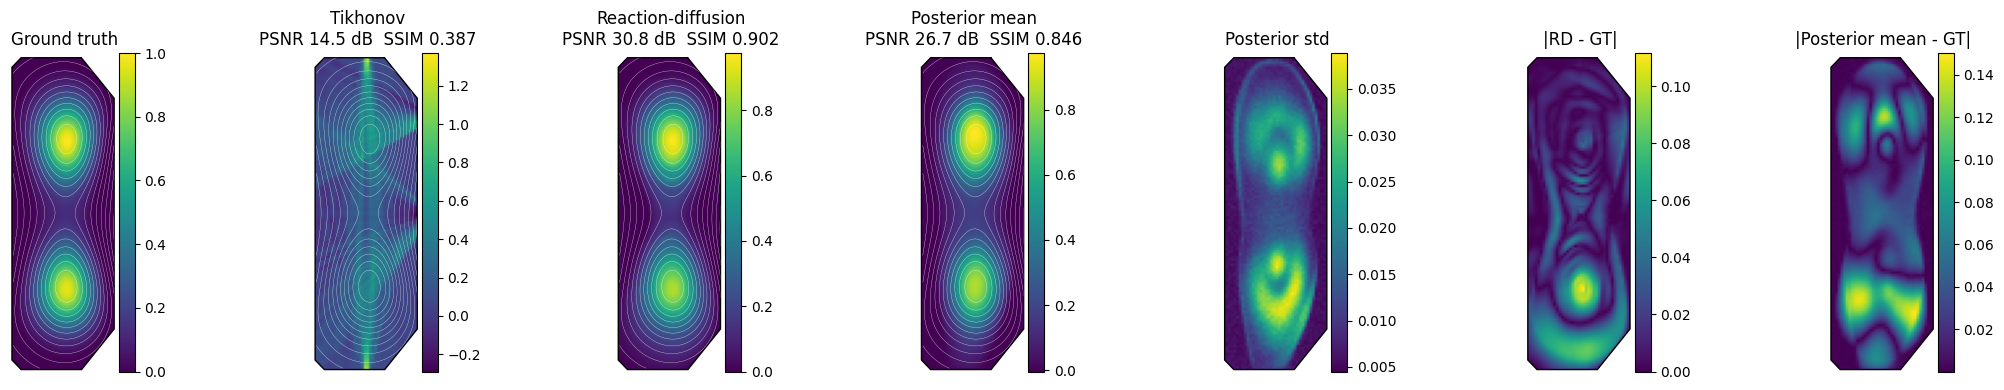

In [98]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean = posterior_tomo.mean(dim=0, keepdim=True)
post_std  = posterior_tomo.std(dim=0, keepdim=True) 

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_doublet
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir = (post_mean - x_gt).abs()
diff_map     = (x_map.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    return f"PSNR {p:.1f} dB  SSIM {s:.3f}"

summary = torch.stack([
        x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map[0, 0].cpu(),
    post_mean[0, 0].cpu(),
    post_std[0, 0].cpu(),
    diff_map[0, 0].cpu(),
    diff_diffpir[0, 0].cpu(),
])

show_samples(
    summary,
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion\n{metrics(x_map.to(device))}",
        f"Posterior mean\n{metrics(post_mean)}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi_doublet, psi_doublet, psi_doublet, psi_doublet, None, None, None],
    colorbar=True,
    vmax=None,#x_gt[0, 0].cpu().max(),#,[x_gt[0, 0].cpu().max(), None, x_gt[0, 0].cpu(), x_gt[0, 0].cpu(), None, None, None]
    #vmax = x_gt.abs().max().item()
)

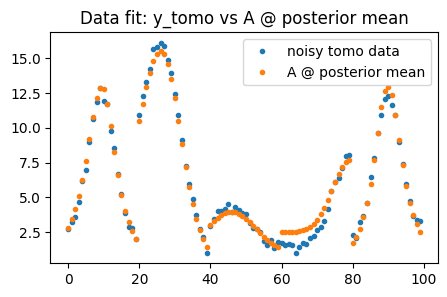

Text(0.5, 1.0, 'Data fit: y_tomo vs A @ RD_MAP_estimate')

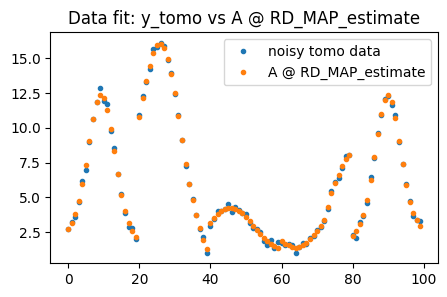

In [99]:
plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ post_mean.view(-1).cpu().numpy(), '.', label="A @ posterior mean")
plt.legend()
plt.title("Data fit: y_tomo vs A @ posterior mean")
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(noisy_tomo_data.flatten(), '.', label="noisy tomo data")
plt.plot(A_tomo.cpu().numpy() @ x_map.view(-1).cpu().numpy(), '.', label="A @ RD_MAP_estimate")
plt.legend()
plt.title("Data fit: y_tomo vs A @ RD_MAP_estimate")

## 4) Perturbed magnetic equilibrium

Trimming values for perturbation: [  0 117   0  38]


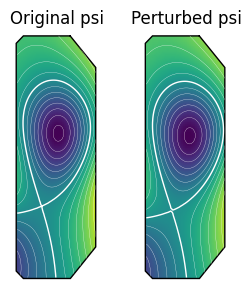

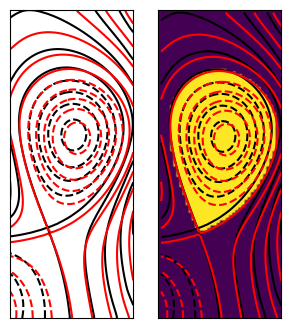

In [18]:
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
sample_idx = 21
psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]

upper_t, lower_t, hfs_t, lfs_t = 6, 5, 3, 2
upper_trim = int(upper_t * np.random.rand())
lower_trim = int(H - lower_t * np.random.rand())
hfs_trim = int(hfs_t * np.random.rand())
lfs_trim = int(W - lfs_t * np.random.rand())
trimming_vals_perturb = np.array([upper_trim, lower_trim, hfs_trim, lfs_trim])
print("Trimming values for perturbation:", trimming_vals_perturb)
psi_perturb = skimt.resize(psi[upper_trim:lower_trim, hfs_trim:lfs_trim], (H,W), anti_aliasing=True,mode='edge')

summary = torch.stack([
        torch.from_numpy(psi).view(1,1,H,W),
        torch.from_numpy(psi_perturb).view(1,1,H,W)
])
show_samples(summary, titles=["Original psi", "Perturbed psi"], contour_images=[psi,psi_perturb])


# define core for perturbed psi
#trim_val_ = trim_val_ + np.array([upper_trim, lower_trim, hfs_trim, lfs_trim])
mask_core_base = tomo_helps.define_core_mask(
                    psi=psi, dim_shape=(H, W), trim_values_x=trim_val_)

xpoint_loc = int(H * (90 - trim_val_[0]) / (trim_val_[1] - trim_val_[0]) )
mask_core = tomo_helps.define_core_mask(
                    psi=psi_perturb, dim_shape=(H, W), xpoint_idx_base_psi=xpoint_loc, trim_values_x=trimming_vals_perturb)

fig,ax=plt.subplots(1,2,figsize=(3.5,4))
ax[0].contour(psi, levels=10, colors="k", origin="upper")
ax[0].contour(psi_perturb, levels=10, colors="r", origin="upper")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].imshow(mask_core, aspect="auto")
ax[1].contour(psi, levels=10, colors="k", origin="lower")
ax[1].contour(psi_perturb, levels=10, colors="r", origin="lower")
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.show()


In [14]:
# mask_diff=mask_core.astype(float) - mask_core_base.astype(float)
# plt.imshow(mask_diff, aspect=None)
# print(np.sum(mask_diff[:60,18]))
# print(100*np.sum(mask_diff[:60,18])*(1.5/H), " cm\n")

# plt.imshow(mask_diff, aspect=None)
# print(np.sum(mask_diff[60:,16]))
# print(100*np.sum(mask_diff[60:,16])*(1.5/H), " cm\n")

# plt.imshow(mask_diff, aspect=None)
# print(np.sum(mask_diff[53,:20]))
# print(100*np.sum(mask_diff[53,:20])*(1.5/H), " cm\n")

# plt.imshow(mask_diff, aspect=None)
# print(np.sum(mask_diff[52,20:]))
# print(100*np.sum(mask_diff[52,20:])*(1.5/H), " cm\n")

In [28]:
csv_naa = pd.read_csv("metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk0_0.25_false.csv")
chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_perturbed_psi_{diag}_chunk*_{sigma}_{proc_str}.csv"))

In [29]:
chunk_csvs

[PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk0_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk10_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk11_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk12_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk13_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk14_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk15_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_chunk16_0.25_false.csv'),
 PosixPath('metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/met

In [33]:
import numpy as np
import pandas as pd
from pathlib import Path

H, W = 120, 40
diags        = ["sxr"]#, "pilatus"]
noise_levels = {}
noise_levels["sxr"] = [0.25]
procedures   = ["false"]
num_samples  = 1000

csv_dir_out = Path("metrics_csv_phantom_analysis_perturbed_psi_sxr_rd")
csv_dir_out.mkdir(exist_ok=True)

for diag in diags:
    print(f"\n{'='*60}")
    print(f"Processing diagnostic: {diag}")
    print(f"{'='*60}")

    csv_dir_in = Path(f"metrics_csv_phantom_analysis_perturbed_psi_sxr_rd")

    # --------------------------------------------------------------------------
    # 1. Merge chunked CSVs into one CSV per (noise_level, procedure)
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_perturbed_psi_{diag}_chunk*_{sigma}_{proc_str}.csv"))
            if not chunk_csvs:
                print(f"No chunks found for sigma={sigma}, procedure={proc_str}, skipping...")
                continue

            df = pd.concat([pd.read_csv(f) for f in chunk_csvs], ignore_index=True)
            df = df.sort_values("sample_idx").reset_index(drop=True)

            out_csv = csv_dir_out / f"metrics_rd_perturbed_psi_{diag}_{sigma}_{proc_str}.csv"
            df.to_csv(out_csv, index=False)
            print(f"Saved {out_csv}  ({len(df)} rows)")

    # --------------------------------------------------------------------------
    # 2. Merge all per-combination CSVs into one global dataframe per diag
    # --------------------------------------------------------------------------
    all_dfs = []
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            csv_path = csv_dir_out / f"metrics_rd_perturbed_psi_{diag}_{sigma}_{proc_str}.csv"
            if csv_path.exists():
                all_dfs.append(pd.read_csv(csv_path))

    if all_dfs:
        df_all = pd.concat(all_dfs, ignore_index=True)
        df_all = df_all.sort_values(["sigma_y_tomo", "procedure", "sample_idx"]).reset_index(drop=True)
        df_all.to_csv(csv_dir_out / f"metrics_rd_perturbed_psi_{diag}_all.csv", index=False)
        print(f"\nSaved global CSV for {diag} with {len(df_all)} rows")
        print(df_all.describe()[["psnr_map", "ssim_map", "mse_map", "psnr_mean", "ssim_mean", "mse_mean"]])

    # --------------------------------------------------------------------------
    # 3. Stack per-sample .npy files into (1000, H, W) arrays
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            maps  = np.zeros((num_samples, H, W), dtype=np.float32)
            means = np.zeros((num_samples, H, W), dtype=np.float32)
            stds  = np.zeros((num_samples, H, W), dtype=np.float32)

            missing = []
            for idx in range(num_samples):
                npy_path = csv_dir_in / f"results_{diag}_{sigma}_{proc_str}_{idx}.npy"
                if not npy_path.exists():
                    missing.append(idx)
                    continue
                data = np.load(npy_path, allow_pickle=True).item()
                maps[idx]  = data["im_MAP"]
                means[idx] = data["mean"]
                stds[idx]  = data["std"]

            if missing:
                print(f"WARNING: {len(missing)} missing .npy files for "
                      f"{diag}, sigma={sigma}, proc={proc_str}: indices {missing}")

            np.save(csv_dir_out / f"maps_perturbed_psi_{diag}_{sigma}_{proc_str}.npy",       maps)
            np.save(csv_dir_out / f"post_means_perturbed_psi_{diag}_{sigma}_{proc_str}.npy", means)
            np.save(csv_dir_out / f"post_stds_perturbed_psi_{diag}_{sigma}_{proc_str}.npy",  stds)
            print(f"Saved stacked arrays for {diag}, sigma={sigma}, procedure={proc_str}  "
                  f"— shape {maps.shape}")


Processing diagnostic: sxr
Saved metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_0.25_false.csv  (1000 rows)

Saved global CSV for sxr with 1000 rows
          psnr_map     ssim_map      mse_map    psnr_mean    ssim_mean  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     32.416493     0.936929     0.000728    30.976144     0.903595   
std       3.317347     0.032345     0.000585     2.850711     0.043213   
min      23.013447     0.797436     0.000082    22.583326     0.743983   
25%      30.078268     0.916545     0.000326    29.018620     0.879245   
50%      32.176478     0.941621     0.000584    30.849633     0.909531   
75%      34.849968     0.961843     0.000932    32.865329     0.935020   
max      40.861382     0.990555     0.004940    39.999775     0.988677   

          mse_mean  
count  1000.000000  
mean      0.000947  
std       0.000651  
min       0.000100  
25%       0.000507  
50%       0.000789  
75% 

In [36]:
# check psi perturbation sxr rd results

noise_levels = [0.25]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/metrics_rd_perturbed_psi_sxr_{noise}_false.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.25
MSE (MAP): 0.000728 +- 0.0006
SSIM (MAP): 0.936929 +- 0.0323
PSNR (MAP): 32.416493 +- 3.3173
MSE (Mean): 0.000947 +- 0.0007
SSIM (Mean): 0.903595 +- 0.0432
PSNR (Mean): 30.976144 +- 2.8507




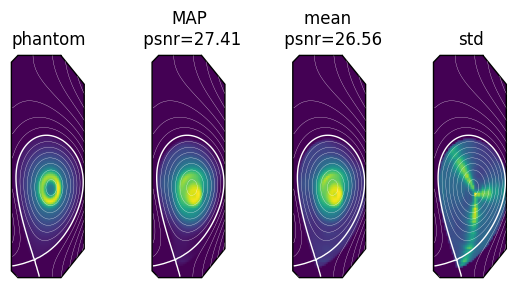

In [46]:
idx_to_be_plotted = 5

means,stds = np.load("metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/post_means_perturbed_psi_sxr_0.25_false.npy")[idx_to_be_plotted,:],\
                np.load("metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/post_stds_perturbed_psi_sxr_0.25_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_perturbed_psi_sxr_rd/maps_perturbed_psi_sxr_0.25_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(results[0]['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(results[0]['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])